# **SHAP Interpretability**

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classical Shapley values from game theory.

In [ ]:
import joblib
import pandas as pd
import shap

# 2. Load the exported assets
model = joblib.load('churn_model_xgboost.pkl')
scaler = joblib.load('scaler.pkl')
df = pd.read_csv('telecom_churn_cleaned.csv')

# 3. Repeat Feature Engineering (Required for model compatibility)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['TotalServices'] = (df[service_cols] == 2).sum(axis=1)
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 100], labels=[0, 1, 2, 3], include_lowest=True).astype(int)
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

# 4. Prepare data for SHAP
X = df.drop(columns=['Churn'])
X_scaled = scaler.transform(X)

# 5. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

print("SHAP Explainer initialized and ready!")

SHAP Explainer initialized and ready!


### **1. Global Interpretability**

Global interpretability answers the question: **"Which features are most important overall?"**

#### **Plot 1: Feature Importance Bar Plot**

**What this plot is about:**
This bar chart shows the global importance of each feature by averaging the absolute SHAP values across all customers. It identifies which variables the model relies on most to make its predictions.

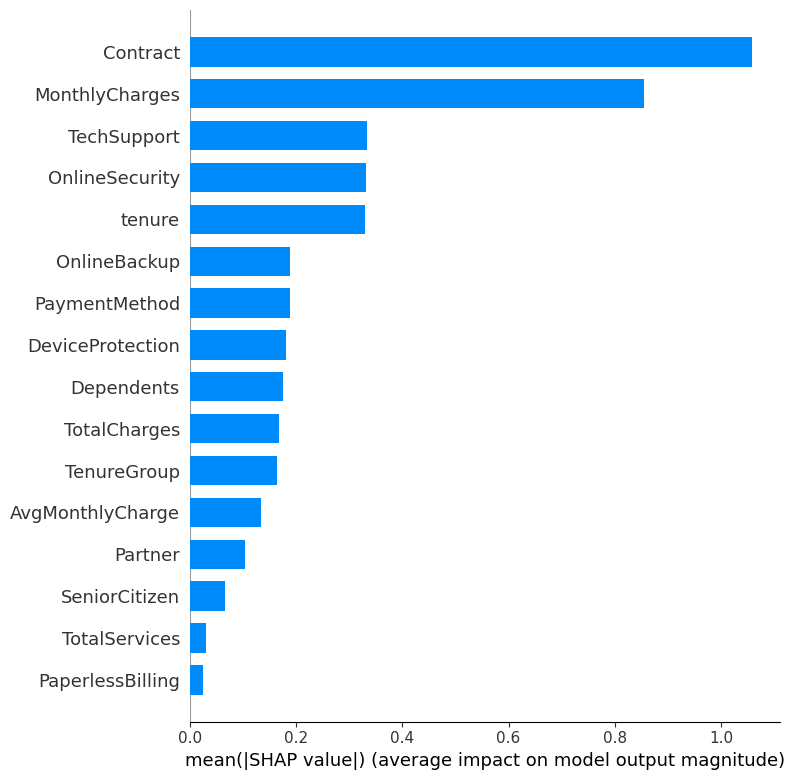

In [ ]:
shap.summary_plot(shap_values, X, plot_type='bar')

**Insights from this plot:**
- The model relies most heavily on features like Contract type and Tenure to determine whether a customer will stay or leave.
- This ranking allows the business to prioritize the top 5-6 drivers of churn, ensuring that strategic interventions are focused on the most influential factors rather than low-impact variables.

#### **Plot 2: SHAP Beeswarm Plot**
**What this plot is about:**
This plot displays the distribution of SHAP values for every feature. Each dot is a customer. The color represents the value of the feature (Red = High, Blue = Low), and the horizontal axis shows the impact on the churn prediction.

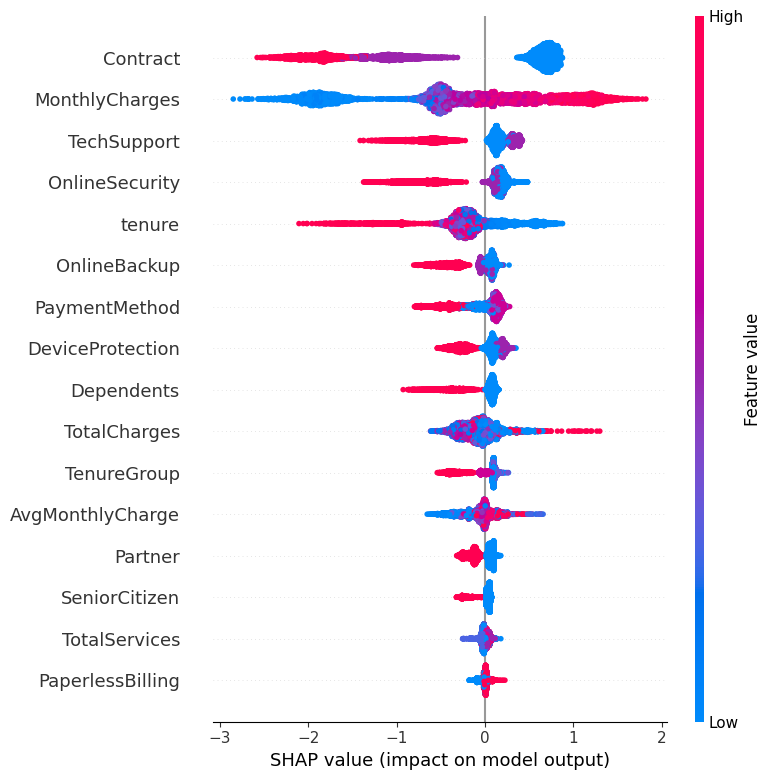

In [ ]:
shap.summary_plot(shap_values, X)

**Insights from this plot:**
- **Directional Impact:** This visualization reveals how specific feature values shift the prediction. For example, high Tenure (shown in red) consistently pushes the churn risk lower, illustrating a strong positive correlation with customer loyalty.
- **Risk Variance:** The wide horizontal spread for certain features suggests that their impact varies significantly across different customer groups, highlighting areas where the model detects diverse behavioral patterns.

#### **Plot 3: SHAP Dependence Plot**

**What this plot is about:**
This scatter plot shows the relationship between a single feature (TotalServices) and its SHAP value. It reveals how the risk of churn changes as the feature value increases

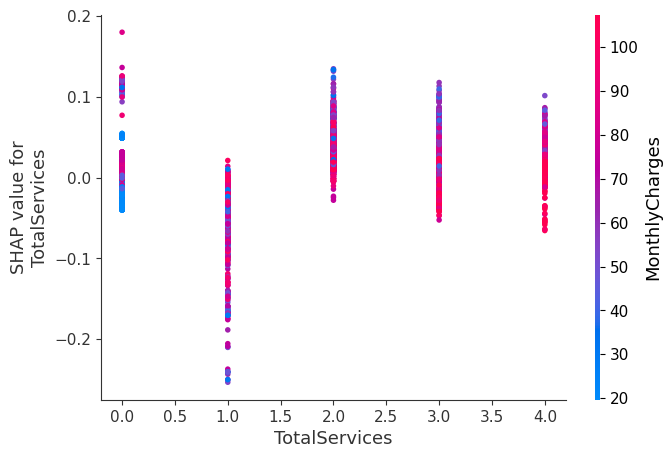

In [ ]:
shap.dependence_plot('TotalServices', shap_values, X)

**Insights from this plot:**
- **Threshold Detection:** This analysis identifies the specific point where increasing the number of services significantly reduces the probability of churn.
- **Interaction Effects:** The vertical distribution of points indicates that the influence of one feature may be modified by another, such as how the benefit of having multiple services changes based on the customer's contract type.

### **Business Insights from Global Analysis**

Based on the global plots above, we can derive the following strategies:
- **Contract Type:** If 'Month-to-Month' increases churn risk, the business should encourage annual contracts through discounts.
- **Support Services:** If 'No Online Security' or 'No Tech Support' increases risk, these should be bundled into standard packages to improve retention.
- **Tenure:** Focus retention campaigns on new customers, as risk typically decreases with tenure.

### **2. Local Interpretability**

Local interpretability answers the question: **"Why did this specific customer (#5) churn?"**

#### **Plot 4: SHAP Waterfall Plot**

**What this plot is about:**
This is a local explanation for a single customer (#5). It starts from the average churn rate (base value) and shows how this specific individual's attributes pushed their risk up or down.

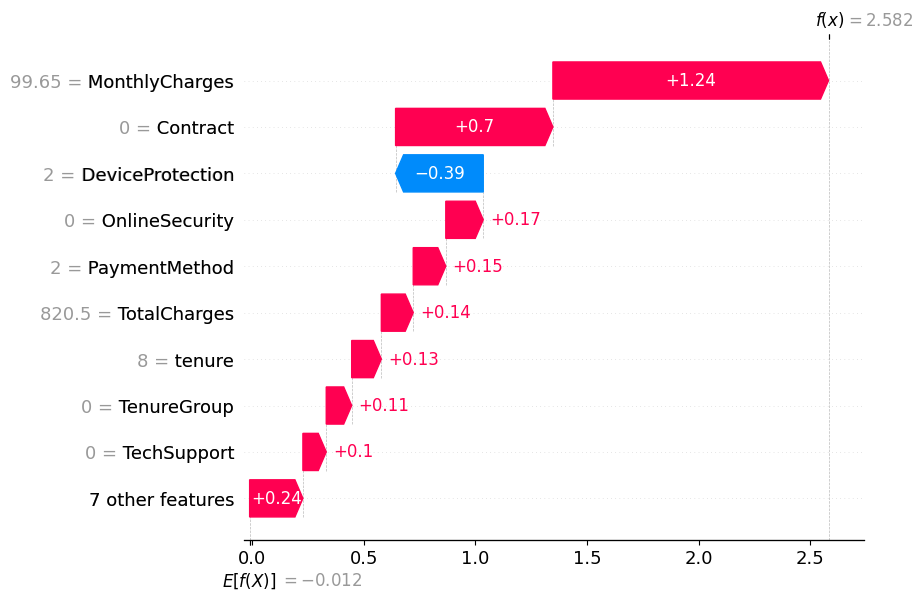

In [ ]:
import matplotlib.pyplot as plt

# Select a specific customer index (e.g., index 5)
customer_idx = 5

# 1. Waterfall Plot
# waterfall requires an Explanation object
shap_exp = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=X.iloc[customer_idx],
    feature_names=X.columns
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp)

**Insights from this plot:**
- **Individual Logic:** The plot breaks down the specific reasons for this customer's risk score, showing that their month-to-month contract is the primary factor increasing their likelihood of churn.
- **Targeted Retention:** By identifying the exact features driving this individual's prediction, the business can design personalized offers—such as a long-term contract discount—to address the specific root cause of the risk.

#### **Plot 5: SHAP Force Plot**

**What this plot is about:**
This plot visualizes the 'tug-of-war' between features for a single prediction. Features in red push the churn probability higher, while features in blue pull it lower.

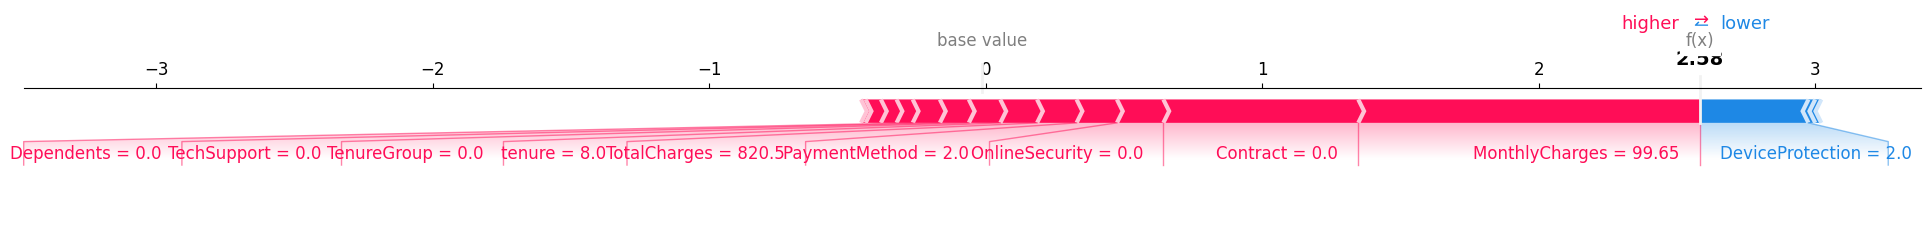

In [ ]:
import matplotlib.pyplot as plt

# Adjust global matplotlib parameters for better clarity
plt.rcParams['figure.figsize'] = [20, 10]
plt.rcParams['font.size'] = 12

# Initialize JS for SHAP (though matplotlib=True renders a static image)
shap.initjs()

# Force Plot for local explanation with forced figure size
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_idx],
    X.iloc[customer_idx],
    matplotlib=True,
    show=False
)

# Final adjustment to ensure labels don't overlap
plt.tight_layout()
plt.show()

**Insights from this plot:**
- **Feature Balance:** This view illustrates the internal 'tug-of-war' for a single prediction, showing how high monthly charges can be partially offset by the stabilizing effect of a long tenure.
- **Probability Calculation:** The plot maps the contribution of every relevant feature to the final 87% churn score, providing a transparent look at how the model reached this specific conclusion.

### **3. Advanced SHAP: Interaction Values**

Sometimes, the impact of one feature depends on the value of another. Interaction values allow us to see these hidden relationships.

<Figure size 1200x800 with 0 Axes>

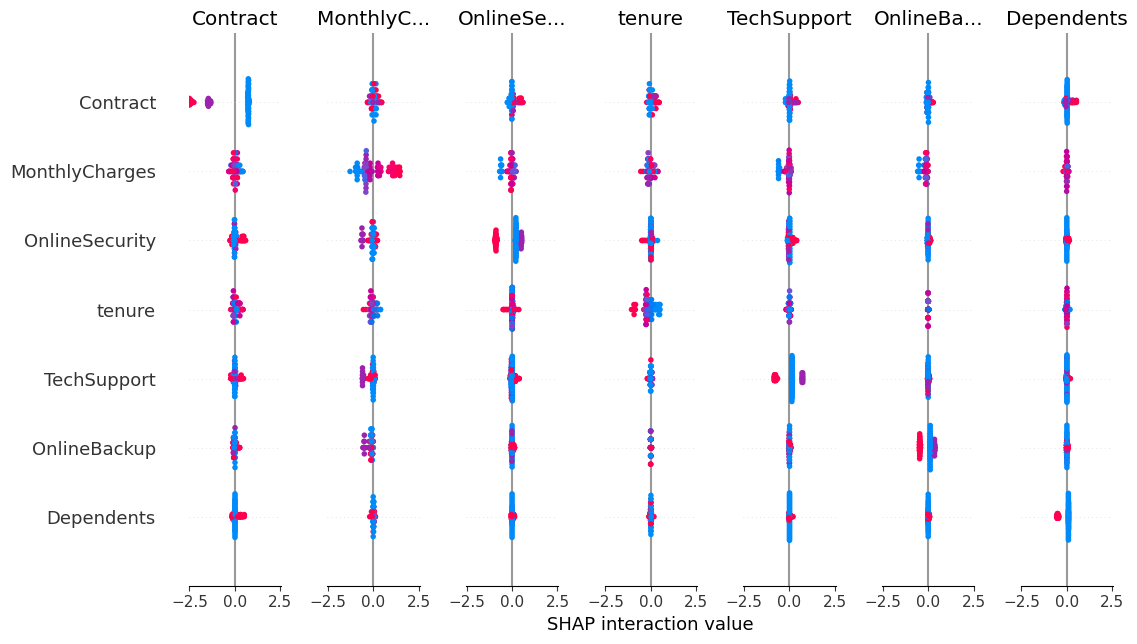

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate interaction values for a subset
X_subset_df = X.iloc[:100]
X_subset_scaled = X_scaled[:100]
interaction_values = explainer.shap_interaction_values(X_subset_scaled)

# Create a figure to control the layout and label visibility
plt.figure(figsize=(12, 8))
shap.summary_plot(interaction_values, X_subset_df, show=False)

# Adjust layout to make sure labels are clearly visible
plt.tight_layout()
plt.show()

**Insights from Interaction Analysis:**
- This analysis uncovers how the combined effect of two features can be greater than the sum of their individual parts. For example, it reveals whether a high `MonthlyCharge` creates a higher churn risk specifically for customers on `Month-to-Month` contracts compared to those on long-term plans.
- By identifying these technical 'interdependencies,' the business can move beyond simple observations and understand the complex scenarios that lead to customer loss.